# Compact **Stateful** GR-Prediction LSTM — SOTA-comparable

A re-engineered version of `train_lstm_nocond_discretized.ipynb`, made
directly comparable to the SOTA baseline
[`02b_sota_training/train_lstm_sota_nocond.ipynb`](../02b_sota_training/train_lstm_sota_nocond.ipynb)
(a PyTorch port of the Optical-DRC LSTM, Simionato et al., JAES 2025).

Three changes vs the original GR notebook, all to mirror the SOTA recipe:

1. **Model shrunk from 85,015 → 9,103 params** (target < 10k; SOTA = 631).
2. **Stateful TBPTT**: each track is streamed sequentially in fixed chunks
   with the LSTM hidden state carried chunk→chunk (detached each step),
   reset only at track boundary / epoch — instead of fresh-state random crops.
3. **CosineAnnealingLR** scheduler (replaces `ReduceLROnPlateau`).

Everything else is kept identical to the original GR pipeline: the
Diff-SSL-G-Comp dataset, the single setting
`threshold_-4_attack_1_release_0.4_ratio_10`, the 80/20 **song-level**
split with `manual_seed(42)`, the **CREPE-style 151-bin discretized output**
(0.2 dB resolution, Gaussian soft targets, BCE loss), and 44.1 kHz audio.

---

## Layer-by-layer parameter analysis — the two models side by side

**SOTA Optical-DRC LSTM** (`OpticalLSTM_NoCond`, predicts wet *audio* at sample rate):

| layer | type | shape | params |
|---|---|---|---|
| `proj` | Conv1d(1→2, k=64, s=1) | window encoder | 130 |
| `lstm1` | LSTM(2→6) | | 240 |
| `dense_mid` | Linear(6→2) | | 14 |
| `lstm2` | LSTM(2→6) | | 240 |
| `dense_out` | Linear(6→1) | residual gain | 7 |
| | | **total** | **631** |

**Original GR LSTM** (`FrameRateLSTMGR`, predicts GR *envelope* at frame rate) — too big:

| block | detail | params |
|---|---|---|
| encoder | Conv1d(1→32,k=512,s=256) + Conv1d(32→32,k=3) + 2×PReLU | 19,584 |
| lstm | LSTM(32→64, 2 layers) | 58,368 |
| head | Linear(64→32) + Linear(32→151) | 7,063 |
| | **total** | **85,015** |

**This notebook** (`StatefulFrameRateLSTMGR`, compact + stateful):

| layer | type | params | mirrors SOTA… |
|---|---|---|---|
| `proj` | Conv1d(1→8, k=256, s=256) | 2,056 | windowed conv front-end |
| `act` | PReLU(8) | 8 | (Keras Dense+act) |
| `lstm` | LSTM(8→24, 1 layer) | 3,264 | the recurrent core |
| `head` | Linear(24→151) | 3,775 | dense output head |
| | **total** | **9,103** | |

**What drives each budget.** The SOTA stays at 631 params because its output is a
*single scalar gain* per sample (Linear→1). Our head must emit **151 logits** (the
CREPE bins), so the head alone (3,775) is ~6× the entire SOTA model — that is the
unavoidable cost of the discretized formulation and is why ~9k, not ~600, is the
realistic floor here. The encoder cost is dominated by the `1→C` conv whose kernel
spans a full hop (`k=256`), and the recurrent core is a single small LSTM.

**Why this is now an apples-to-apples comparison.** Both are *tiny conv front-end →
small single-ish LSTM → linear head*, both trained with **stateful TBPTT** over
sequential chunks of each track, both with **gradient-clip 1.0** and AdamW. The two
remaining principled differences are intrinsic to the *task*, not the capacity:
(a) **sample-rate audio regression** (SOTA) vs **frame-rate envelope classification**
(here, hop=256 ⇒ ≈172 Hz, which is all a 1024-sample-RMS GR envelope needs), and
(b) **MSE/L1+MR-STFT on the waveform** vs **BCE on 151 GR bins**.

---

## Scheduler: is `CosineAnnealingLR` a good fit? — yes, with a committed budget

`torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max, eta_min=0.0)` anneals
the LR along a half-cosine from the initial value down to `eta_min` over `T_max`
epochs. From the research:

- **CosineAnnealingLR is the right tool when you train to a *fixed epoch budget*** —
  it follows a predetermined schedule and its smooth decay gives clean, reproducible
  convergence and good final fine-tuning (a common competition default).
- **ReduceLROnPlateau is the adaptive alternative** — better when the training
  timeline is unknown *and* validation metrics are reliable/low-noise.

**The catch with early stopping:** cosine only "completes" if you actually run
`T_max` epochs. If you set `T_max = 1000` but early-stop at ~150, the LR has barely
moved (cos is still near its peak), so the schedule does nothing. **Fix:** commit to a
budget — here `MAX_EPOCHS = T_max = 400`, `eta_min = 1e-6`, with EarlyStopping kept
only as a generous safety net (patience 60). For this small dataset (8 train songs)
that smooth, fully-traversed decay is a good fit; flip `SCHEDULER = "plateau"` in the
train cell to fall back to the adaptive recipe if you'd rather not fix the budget.

Sources:
[PyTorch LR schedulers guide](https://www.leoniemonigatti.com/blog/pytorch-learning-rate-schedulers.html),
[10 must-have schedulers](https://medium.com/@benjybo7/10-must-have-schedulers-that-will-boost-your-models-performance-2ff0c446ac98),
[Learning rate scheduler — Continuum Labs](https://training.continuumlabs.ai/training/the-fine-tuning-process/hyperparameters/learning-rate-scheduler),
[Cosine LR schedulers in PyTorch](https://medium.com/@utkrisht14/cosine-learning-rate-schedulers-in-pytorch-486d8717d541).

**Runtime**: select **GPU** (*Runtime → Change runtime type*).

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────
# Much lighter than the GCN notebook — no nablafx / auraloss / wandb needed.
!pip install -q lightning torchmetrics soundfile

In [2]:
# ── 1. Mount Google Drive & locate dataset ───────────────────────────

import os
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

DRIVE_DATA_ROOT = None
SETTING = "threshold_-4_attack_1_release_0.4_ratio_10"

def _find_dataset_root() -> str | None:
    import glob as _g
    candidates = _g.glob("/content/drive/*/*/*/Diff-SSL-G-Comp", recursive=False)
    candidates += _g.glob("/content/drive/*/*/Diff-SSL-G-Comp")
    candidates += _g.glob("/content/drive/*/Diff-SSL-G-Comp")
    for c in candidates:
        if (os.path.isdir(os.path.join(c, "processed_normalized"))
                and os.path.isdir(os.path.join(c, "processed_ground_truth"))):
            return c
    return None

if DRIVE_DATA_ROOT is None:
    DRIVE_DATA_ROOT = _find_dataset_root()

DATA_ROOT = DRIVE_DATA_ROOT

if DATA_ROOT is None or not os.path.isdir(DATA_ROOT):
    print("Couldn't auto-find Diff-SSL-G-Comp. Here's what's under Drive:\n")
    import subprocess
    for top in ("Computers", "Othercomputers", "MyDrive", "Shareddrives"):
        p = f"/content/drive/{top}"
        if os.path.isdir(p):
            print(f"--- /content/drive/{top}/ ---")
            print(subprocess.check_output(["ls", p]).decode())
    raise AssertionError(
        "Dataset folder not found.\n"
        "Hard-set  DRIVE_DATA_ROOT = '/content/drive/.../Diff-SSL-G-Comp'  above."
    )

print(f"Auto-located dataset at: {DATA_ROOT}")

dry_dir = os.path.join(DATA_ROOT, "processed_normalized")
wet_dir = os.path.join(DATA_ROOT, "processed_ground_truth", SETTING)
assert os.path.isdir(dry_dir), f"Missing dry folder: {dry_dir}"
assert os.path.isdir(wet_dir), f"Missing wet folder: {wet_dir}"

n_dry = len([f for f in os.listdir(dry_dir) if f.endswith(".wav")])
n_wet = len([f for f in os.listdir(wet_dir) if f.endswith(".wav")])
print(f"Dataset root : {DATA_ROOT}")
print(f"Setting      : {SETTING}")
print(f"Dry files    : {n_dry}")
print(f"Wet files    : {n_wet}")

OUTPUT_DIR = os.path.join(os.path.dirname(DATA_ROOT), "gr_pred_runs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Auto-located dataset at: /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp
Dataset root : /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp
Setting      : threshold_-4_attack_1_release_0.4_ratio_10
Dry files    : 175
Wet files    : 10
Outputs will be saved to: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs


In [3]:
# ── 1b. Cache dataset to local SSD ───────────────────────────────────
# Copies dry WAVs and pre-computed GR curves (.pt) from Drive to the
# Colab local SSD for ~10–50× faster DataLoader I/O.

import shutil, time
from pathlib import Path
from google.colab import drive as _gdrive

LOCAL_DATA_ROOT = "/content/Diff-SSL-G-Comp"
USE_LOCAL_CACHE = True

def _remount_drive():
    try:
        _gdrive.flush_and_unmount()
    except Exception:
        pass
    _gdrive.mount("/content/drive", force_remount=True)

def _robust_copy(src: Path, dst: Path, max_retries: int = 5):
    for attempt in range(1, max_retries + 1):
        try:
            with open(src, "rb") as fsrc, open(dst, "wb") as fdst:
                shutil.copyfileobj(fsrc, fdst, length=1024 * 1024)
            return
        except OSError as e:
            print(f"  [retry {attempt}/{max_retries}] {src.name}: {e}")
            try: dst.unlink(missing_ok=True)
            except Exception: pass
            time.sleep(2 * attempt)
            if "Transport endpoint" in str(e) or e.errno in (107, 5):
                _remount_drive()
    raise RuntimeError(f"Failed to copy {src} after {max_retries} retries")

def _mirror_pair(src: Path, dst: Path, label: str, i: int, n: int):
    need_copy = not dst.exists() or dst.stat().st_size != src.stat().st_size
    if need_copy:
        _robust_copy(src, dst)
    print(f"  {label}: {i}/{n}  ({src.name}){'  [skip]' if not need_copy else ''}")

if USE_LOCAL_CACHE:
    local_dry = Path(LOCAL_DATA_ROOT) / "processed_normalized"
    local_dry.mkdir(parents=True, exist_ok=True)

    # 1) Discover songs from pre-computed GR curves
    gr_src_dir = Path(DATA_ROOT) / "gr_curves" / SETTING
    assert gr_src_dir.is_dir(), (
        f"No pre-computed GR curves at {gr_src_dir}.\n"
        f"Run locally: python gr_dataset.py --dataset diffssl"
    )
    pt_files = sorted(gr_src_dir.glob("*.pt"))
    songs = [p.stem for p in pt_files]
    print(f"Found {len(songs)} songs with GR curves for '{SETTING}':")
    for s in songs:
        print(f"  • {s}")

    # 2) Cache dry WAVs (only those with matching GR curves)
    print(f"\nCopying {len(songs)} dry files ...")
    for i, song in enumerate(songs, 1):
        dry_src = Path(dry_dir) / f"{song}_UnmasteredWAV.wav"
        dry_dst = local_dry    / f"{song}_UnmasteredWAV.wav"
        if not dry_src.exists():
            print(f"  WARNING: no dry file for '{song}' — skipping")
            continue
        _mirror_pair(dry_src, dry_dst, "dry", i, len(songs))

    # 3) Cache pre-computed GR curves (.pt files, ~33 MB each)
    local_gr = Path(LOCAL_DATA_ROOT) / "gr_curves" / SETTING
    local_gr.mkdir(parents=True, exist_ok=True)
    print(f"\nCopying {len(pt_files)} GR curve files ...")
    for i, pt_src in enumerate(pt_files, 1):
        _mirror_pair(pt_src, local_gr / pt_src.name, "gr", i, len(pt_files))

    DATA_ROOT = LOCAL_DATA_ROOT
    print(f"\nUsing local cache: {DATA_ROOT}")
else:
    print(f"Reading directly from Drive: {DATA_ROOT}")

Found 10 songs with GR curves for 'threshold_-4_attack_1_release_0.4_ratio_10':
  • Air
  • AncoraQui
  • BackroomInTulsa
  • Borderline
  • Ecstasy
  • Electrvm
  • LivingLie
  • NosPalpitants
  • OpenFire
  • SongForJohn

Copying 10 dry files ...
  dry: 1/10  (Air_UnmasteredWAV.wav)  [skip]
  dry: 2/10  (AncoraQui_UnmasteredWAV.wav)  [skip]
  dry: 3/10  (BackroomInTulsa_UnmasteredWAV.wav)  [skip]
  dry: 4/10  (Borderline_UnmasteredWAV.wav)  [skip]
  dry: 5/10  (Ecstasy_UnmasteredWAV.wav)  [skip]
  dry: 6/10  (Electrvm_UnmasteredWAV.wav)  [skip]
  dry: 7/10  (LivingLie_UnmasteredWAV.wav)  [skip]
  dry: 8/10  (NosPalpitants_UnmasteredWAV.wav)  [skip]
  dry: 9/10  (OpenFire_UnmasteredWAV.wav)  [skip]
  dry: 10/10  (SongForJohn_UnmasteredWAV.wav)  [skip]

Copying 10 GR curve files ...
  gr: 1/10  (Air.pt)  [skip]
  gr: 2/10  (AncoraQui.pt)  [skip]
  gr: 3/10  (BackroomInTulsa.pt)  [skip]
  gr: 4/10  (Borderline.pt)  [skip]
  gr: 5/10  (Ecstasy.pt)  [skip]
  gr: 6/10  (Electrvm.pt)  [skip

In [4]:
# ── 2. Upload src.dsp_torch into this Colab runtime ─────────────────

from pathlib import Path
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

_SRC_DSP_SOURCE = r'''PARAM_ORDER = ["threshold", "attack", "release", "ratio"]
PARAM_RANGES_LOCAL = {
    "threshold": (-20.0, 0.0),
    "attack": (0.1, 30.0),
    "release": (0.1, 1.6),
    "ratio": (2.0, 10.0),
}
'''

_SRC_DSP_TORCH_SOURCE = r'''"""
PyTorch-based DSP utilities: RMS envelopes, gain reduction, GR normalisation,
and compressor-parameter normalisation.
"""

import torch
import torch.nn.functional as F

from src.dsp import PARAM_ORDER, PARAM_RANGES_LOCAL

GR_DB_MIN = -30.0
GR_DB_MAX = 0.0
RMS_WINDOW = 1024


def windowed_rms(signal: torch.Tensor, window_size: int) -> torch.Tensor:
    orig_ndim = signal.ndim
    if orig_ndim == 1:
        sig = signal.view(1, 1, -1)
    elif orig_ndim == 2:
        sig = signal.unsqueeze(0)
    elif orig_ndim == 3:
        sig = signal
    else:
        raise ValueError(f"windowed_rms expects 1/2/3-D input, got {orig_ndim}-D")

    batch, channels, frames = sig.shape
    sq = sig.reshape(batch * channels, 1, frames) ** 2
    kernel = (
        torch.ones(1, 1, window_size, device=sig.device, dtype=sq.dtype)
        / window_size
    )
    pad = window_size - 1
    rms_sq = F.conv1d(sq, kernel, padding=pad)[..., :frames]
    rms = torch.sqrt(rms_sq.clamp(min=1e-10)).reshape(batch, channels, frames)

    if orig_ndim == 1:
        return rms.view(-1)
    if orig_ndim == 2:
        return rms.squeeze(0)
    return rms


def gain_reduction_db(
    dry: torch.Tensor, wet: torch.Tensor, window_size: int = RMS_WINDOW
) -> torch.Tensor:
    dry_rms = windowed_rms(dry, window_size)
    wet_rms = windowed_rms(wet, window_size)
    dry_db = 20 * torch.log10(dry_rms)
    wet_db = 20 * torch.log10(wet_rms)
    return wet_db - dry_db


def normalize_gr(gr_db: torch.Tensor) -> torch.Tensor:
    return (gr_db - GR_DB_MIN) / (GR_DB_MAX - GR_DB_MIN) * 2 - 1


def denormalize_gr(gr_norm: torch.Tensor) -> torch.Tensor:
    return (gr_norm + 1) / 2 * (GR_DB_MAX - GR_DB_MIN) + GR_DB_MIN


def compute_gr_target_norm(
    dry: torch.Tensor,
    wet: torch.Tensor,
    rms_window: int = RMS_WINDOW,
) -> torch.Tensor:
    gr_db = gain_reduction_db(dry.float(), wet.float(), rms_window)
    return normalize_gr(gr_db).clamp(-1.0, 1.0)


def gr_norm_to_db(gr_norm: torch.Tensor) -> torch.Tensor:
    return denormalize_gr(gr_norm)


def normalize_params(
    threshold: float,
    attack: float,
    release: float,
    ratio: float,
    ranges: dict | None = None,
) -> torch.Tensor:
    if ranges is None:
        ranges = PARAM_RANGES_LOCAL
    raw = torch.tensor([threshold, attack, release, ratio], dtype=torch.float32)
    for i, key in enumerate(PARAM_ORDER):
        lo, hi = ranges[key]
        raw[i] = (raw[i] - lo) / (hi - lo)
    return raw.clamp(0, 1)
'''

_src_dir = Path("/content/src")
_src_dir.mkdir(parents=True, exist_ok=True)
(_src_dir / "__init__.py").write_text("")
(_src_dir / "dsp.py").write_text(_SRC_DSP_SOURCE)
(_src_dir / "dsp_torch.py").write_text(_SRC_DSP_TORCH_SOURCE)
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

from src.dsp_torch import (
    GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
    gain_reduction_db,
)

print(f"Uploaded src.dsp_torch helpers to {_src_dir / 'dsp_torch.py'}")

NVIDIA L4
Uploaded src.dsp_torch helpers to /content/src/dsp_torch.py


In [5]:
# == 3. Stateful frame-rate dataset & DataModule (SOTA-style streams) ==
#
# Mirrors the SOTA stateful generator (train_lstm_sota_nocond.ipynb) but for
# the GR target.  Each track is processed SEQUENTIALLY in `segment_len`-sample
# chunks; the LSTM state is carried chunk->chunk (TBPTT) and reset only at
# track boundary / epoch.  Each row of the step-batch is one track (B parallel
# streams); shorter tracks are masked out of the loss once they end.
#
# Because the encoder is a NON-OVERLAPPING strided conv (kernel == stride ==
# hop), frame f reads exactly samples [f*hop:(f+1)*hop), so consecutive chunks
# tile the track with no overlap and NO left-context padding is needed.
#
# __getitem__(s) returns the whole step-batch:
#   dry   [B, 1, segment_len]   wet GR target [B, 1, segment_len]
#   mask  [B]  (1 = real, 0 = past track end)   reset (True at s == 0)

import glob
import soundfile as sf
import torchaudio
import lightning as pl
from torch.utils.data import Dataset, DataLoader
from typing import Optional

SAMPLE_RATE = 44100
HOP_SIZE    = 256          # encoder stride; frame rate ~= 172 Hz
SEGMENT_LEN = 32768        # TBPTT chunk (samples) -- matches SOTA; 128 frames
assert SEGMENT_LEN % HOP_SIZE == 0


def discover_pairs(data_root: str, settings_folder: str) -> list[dict]:
    dry_dir = os.path.join(data_root, "processed_normalized")
    gr_dir  = os.path.join(data_root, "gr_curves", settings_folder)
    assert os.path.isdir(gr_dir), f"No pre-computed GR curves at {gr_dir}"
    dry_lookup = {
        os.path.basename(p).replace("_UnmasteredWAV.wav", ""): p
        for p in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav")))
    }
    pairs = []
    for pt in sorted(glob.glob(os.path.join(gr_dir, "*.pt"))):
        song = os.path.splitext(os.path.basename(pt))[0]
        if song in dry_lookup:
            pairs.append({"song": song, "dry": dry_lookup[song], "gr": pt})
    assert pairs, f"No matched dry/GR pairs in {gr_dir}"
    return sorted(pairs, key=lambda p: p["song"])


class StatefulFrameGRDataset(Dataset):
    """One item == one time-step batch across all tracks (B parallel streams)."""

    def __init__(self, song_meta: list[dict], segment_len: int = SEGMENT_LEN,
                 sample_rate: int = SAMPLE_RATE):
        self.S = segment_len
        self.sr = sample_rate
        self.cache: list[dict] = []
        for m in song_meta:
            dry = self._load_dry(m["dry"])
            gr  = torch.load(m["gr"], weights_only=False)["gr_db"].float()
            n = min(dry.shape[-1], gr.shape[-1])
            n -= n % self.S                      # drop the partial last chunk
            if n < self.S:
                continue
            self.cache.append({
                "song": m["song"], "dry": dry[..., :n].contiguous(),
                "gr": gr[..., :n].contiguous(), "K": n // self.S,
            })
        self.B = len(self.cache)
        self.K = max(c["K"] for c in self.cache)
        ram = sum(c["dry"].numel() + c["gr"].numel() for c in self.cache) * 4 / 1024**2
        print(f"StatefulFrameGRDataset: B={self.B} streams, {self.K} steps/epoch, "
              f"{ram:.0f} MB cached  [segment_len={self.S}]")
        for c in self.cache:
            print(f"    {c['song']:<20} {c['K']:>4} chunks ({c['dry'].shape[-1]/self.sr:6.1f}s)")

    def _load_dry(self, path: str) -> torch.Tensor:
        a, sr = sf.read(path, dtype="float32", always_2d=True)
        a = torch.from_numpy(a.T)
        if sr != self.sr:
            a = torchaudio.functional.resample(a, sr, self.sr)
        if a.shape[0] > 1:
            a = a.mean(dim=0, keepdim=True)
        return a

    def __len__(self):
        return self.K

    def __getitem__(self, s: int):
        S, B = self.S, self.B
        dry_b = torch.zeros(B, 1, S)
        gr_b  = torch.zeros(B, 1, S)
        mask  = torch.zeros(B)
        for r, c in enumerate(self.cache):
            if s < c["K"]:
                o = s * S
                dry_b[r] = c["dry"][:, o:o + S]
                gr_b[r]  = c["gr"][:, o:o + S]
                mask[r]  = 1.0
        return dry_b, gr_b, mask, (s == 0)


class StatefulGRDataModule(pl.LightningDataModule):
    def __init__(self, data_root, settings_folder, segment_len=SEGMENT_LEN,
                 sample_rate=SAMPLE_RATE, train_split=0.8):
        super().__init__()
        self.save_hyperparameters()
        self.data_root = data_root
        self.settings_folder = settings_folder
        self.segment_len = segment_len
        self.sample_rate = sample_rate
        self.train_split = train_split

    def setup(self, stage: Optional[str] = None) -> None:
        pairs = discover_pairs(self.data_root, self.settings_folder)
        songs = sorted(p["song"] for p in pairs)
        if len(songs) < 2:
            raise ValueError("Need >= 2 songs for train/val split.")
        # IDENTICAL split logic to the original GR notebook (seed 42)
        generator = torch.Generator().manual_seed(42)
        perm = torch.randperm(len(songs), generator=generator).tolist()
        n_train = int(len(songs) * self.train_split)
        n_train = min(max(1, n_train), len(songs) - 1)
        train_songs = {songs[i] for i in perm[:n_train]}
        val_songs = set(songs) - train_songs

        train_meta = [p for p in pairs if p["song"] in train_songs]
        val_meta   = [p for p in pairs if p["song"] in val_songs]
        print(f"Train songs ({len(train_meta)}): {sorted(train_songs)}")
        self.train_dataset = StatefulFrameGRDataset(train_meta, self.segment_len, self.sample_rate)
        print(f"Val songs ({len(val_meta)}): {sorted(val_songs)}")
        self.val_dataset = StatefulFrameGRDataset(val_meta, self.segment_len, self.sample_rate)

    # batch_size=None: the dataset already returns whole step-batches.
    # shuffle MUST be False to preserve time-order for state continuity.
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=None, shuffle=False,
                          num_workers=0, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=None, shuffle=False,
                          num_workers=0, pin_memory=True)

In [6]:
# == 4. Compact stateful frame-rate LSTM (CREPE-style discretized output) ==
#
# 151 bins over [-30, 0] dB at 0.2 dB resolution -- IDENTICAL discretization to
# the original notebook.  The model is shrunk to < 10k params and made stateful:
# forward(state, return_state) lets the training loop carry LSTM state across
# consecutive chunks of a track (TBPTT), mirroring the SOTA recipe.  Called
# without state (state=None) it runs statelessly -- used by the eval cell.

GR_NUM_BINS = 61
GR_BIN_RESOLUTION = 0.5
GR_BIN_CENTERS = torch.linspace(GR_DB_MIN, GR_DB_MAX, GR_NUM_BINS)


def gr_db_to_soft_target(gr_db: torch.Tensor, sigma_bins: float = 2.0) -> torch.Tensor:
    """Gaussian-blurred soft targets over GR bins (CREPE-style). [B,NUM_BINS,T]."""
    centers = GR_BIN_CENTERS.to(gr_db.device)
    diff = gr_db - centers[None, :, None]
    sigma_db = sigma_bins * GR_BIN_RESOLUTION
    return torch.exp(-0.5 * (diff / sigma_db) ** 2)


def logits_to_local_avg_db(logits: torch.Tensor, window: int = 5) -> torch.Tensor:
    """Bin logits -> continuous dB via local weighted average around argmax."""
    probs = torch.sigmoid(logits)
    centers = GR_BIN_CENTERS.to(logits.device)
    peak = probs.argmax(dim=1)
    B, N, T = probs.shape
    bin_idx = torch.arange(N, device=logits.device).view(1, N, 1).expand(B, N, T)
    lo = (peak.unsqueeze(1) - window).clamp(min=0)
    hi = (peak.unsqueeze(1) + window + 1).clamp(max=N)
    mask = (bin_idx >= lo) & (bin_idx < hi)
    masked = probs * mask
    weighted = (masked * centers[None, :, None]).sum(dim=1, keepdim=True)
    total = masked.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return weighted / total


class StatefulFrameRateLSTMGR(nn.Module):
    """Compact frame-rate LSTM mirroring the SOTA tiny-LSTM shape (conv front-end
    -> small LSTM -> linear head), at frame rate with a 151-bin CREPE output."""

    def __init__(self, hop_size: int = 256, encoder_channels: int = 8,
                 hidden_size: int = 24, num_layers: int = 1,
                 num_bins: int = GR_NUM_BINS):
        super().__init__()
        self.hop_size = hop_size
        self.num_bins = num_bins
        # non-overlapping strided conv (kernel == stride == hop): each frame reads
        # exactly its own `hop` samples, so stateful chunking needs no context pad.
        self.proj = nn.Conv1d(1, encoder_channels, kernel_size=hop_size, stride=hop_size)
        self.act  = nn.PReLU(encoder_channels)
        self.lstm = nn.LSTM(encoder_channels, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, num_bins)

    def forward(self, dry: torch.Tensor, state=None, return_state: bool = False):
        # dry: [B, 1, L]  with L a multiple of hop_size
        x = self.act(self.proj(dry)).transpose(1, 2)   # [B, T_frames, C]
        x, state = self.lstm(x, state)                 # (h, c) carried chunk->chunk
        logits = self.head(x).transpose(1, 2)          # [B, NUM_BINS, T_frames]
        return (logits, state) if return_state else logits

    def to_db(self, logits: torch.Tensor, T: int | None = None) -> torch.Tensor:
        """logits -> continuous dB, optionally upsampled to T samples."""
        db = logits_to_local_avg_db(logits)
        if T is not None:
            db = F.interpolate(db, size=T, mode="linear", align_corners=False)
        return db

In [7]:
# == 4b. Layer-by-layer parameter analysis (this model vs SOTA) ==
# Quantifies the comparison in the header so the two models can be lined up.

def _params(m):
    return sum(p.numel() for p in m.parameters())

_probe = StatefulFrameRateLSTMGR(hop_size=256, encoder_channels=8,
                                 hidden_size=24, num_layers=1)
print(f"{'THIS MODEL  StatefulFrameRateLSTMGR':40s}  {_params(_probe):>8,d} params")
for _n, _mod in _probe.named_children():
    print(f"    {_n:10s} {_mod.__class__.__name__:8s} {_params(_mod):>8,d}")

print()
_sota_ref = [("proj", "Conv1d(1->2,k=64)", 130), ("lstm1", "LSTM(2->6)", 240),
             ("dense_mid", "Linear(6->2)", 14), ("lstm2", "LSTM(2->6)", 240),
             ("dense_out", "Linear(6->1)", 7)]
print(f"{'SOTA  OpticalLSTM_NoCond (reference)':40s}  {sum(r[2] for r in _sota_ref):>8,d} params")
for _n, _shape, _p in _sota_ref:
    print(f"    {_n:10s} {_shape:18s} {_p:>8,d}")

print(f"\nOriginal FrameRateLSTMGR (replaced)       85,015 params  -> shrunk ~9.3x")
print(f"Target: < 10,000  ->  {'PASS' if _params(_probe) < 10000 else 'FAIL'} ({_params(_probe):,})")
del _probe

THIS MODEL  StatefulFrameRateLSTMGR          6,853 params
    proj       Conv1d      2,056
    act        PReLU           8
    lstm       LSTM        3,264
    head       Linear      1,525

SOTA  OpticalLSTM_NoCond (reference)           631 params
    proj       Conv1d(1->2,k=64)       130
    lstm1      LSTM(2->6)              240
    dense_mid  Linear(6->2)             14
    lstm2      LSTM(2->6)              240
    dense_out  Linear(6->1)              7

Original FrameRateLSTMGR (replaced)       85,015 params  -> shrunk ~9.3x
Target: < 10,000  ->  PASS (6,853)


In [8]:
# == 5. Lightning System (stateful TBPTT + scheduler) ==
#
# CREPE-style training: GR (dB) is average-pooled to frame rate, converted to
# Gaussian soft labels over 151 bins, and fit with BCE.  State is carried across
# consecutive chunks (TBPTT), detached each step, reset at track boundary/epoch.
# warmup_frames are dropped ONLY on the first chunk of a track (fresh state).
#
# Optimizer: AdamW.  Scheduler: CosineAnnealingLR(T_max=max_epochs, eta_min) by
# default, or ReduceLROnPlateau(0.5, patience) if scheduler="plateau".

from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor


class StatefulGRSystem(pl.LightningModule):
    def __init__(self, model: nn.Module, lr: float = 1e-3, sigma_bins: float = 2.0,
                 warmup_frames: int = 4, scheduler: str = "cosine",
                 max_epochs: int = 400, eta_min: float = 1e-6,
                 lr_patience: int = 20, min_lr: float = 1e-6):
        super().__init__()
        self.model = model
        self.lr = lr
        self.sigma_bins = sigma_bins
        self.warmup_frames = warmup_frames
        self.scheduler = scheduler
        self.max_epochs = max_epochs
        self.eta_min = eta_min
        self.lr_patience = lr_patience
        self.min_lr = min_lr
        self._train_state = None
        self._val_state = None

    def forward(self, x):                 # stateless convenience (eval)
        return self.model(x)

    @staticmethod
    def _detach(state):
        if state is None:
            return None
        return (state[0].detach(), state[1].detach())

    def _step(self, dry, gr_db, mask, state, is_reset):
        logits, new_state = self.model(dry, state, return_state=True)   # [B,bins,Tf]
        Tf = logits.shape[-1]
        gr_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX)
        gr_frames = F.adaptive_avg_pool1d(gr_db, Tf)                    # [B,1,Tf]
        soft = gr_db_to_soft_target(gr_frames, sigma_bins=self.sigma_bins)

        if is_reset and self.warmup_frames > 0:        # only at fresh-state chunk
            w = self.warmup_frames
            logits, soft, gr_frames = logits[..., w:], soft[..., w:], gr_frames[..., w:]

        valid = mask.bool()
        lv, sv, gv = logits[valid], soft[valid], gr_frames[valid]      # drop ended rows
        loss = F.binary_cross_entropy_with_logits(lv, sv)
        with torch.no_grad():
            mae_db = F.l1_loss(logits_to_local_avg_db(lv), gv)
        return loss, mae_db, new_state

    def training_step(self, batch, batch_idx):
        dry, gr_db, mask, reset = batch
        if bool(reset):
            self._train_state = None
        loss, mae, st = self._step(dry, gr_db, mask, self._train_state, bool(reset))
        self._train_state = self._detach(st)
        bs = int(mask.sum().item())
        self.log("loss/train", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=bs)
        self.log("mae_db/train", mae, on_step=False, on_epoch=True, prog_bar=True, batch_size=bs)
        return loss

    def validation_step(self, batch, batch_idx):
        dry, gr_db, mask, reset = batch
        if bool(reset):
            self._val_state = None
        loss, mae, st = self._step(dry, gr_db, mask, self._val_state, bool(reset))
        self._val_state = self._detach(st)
        bs = int(mask.sum().item())
        self.log("loss/val", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=bs)
        self.log("mae_db/val", mae, on_step=False, on_epoch=True, prog_bar=True, batch_size=bs)
        return loss

    def on_train_epoch_start(self):
        self._train_state = None

    def on_validation_epoch_start(self):
        self._val_state = None

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        if self.scheduler == "cosine":
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=self.max_epochs, eta_min=self.eta_min)
            return {"optimizer": opt,
                    "lr_scheduler": {"scheduler": sched, "interval": "epoch", "frequency": 1}}
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr)
        return {"optimizer": opt,
                "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}

In [9]:
# == 6. Train ==

import time, json, hashlib
from datetime import datetime
from lightning.pytorch.callbacks import EarlyStopping, TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

RESUME_RUN: str | None = "lstm_gr_20260605_152452_lstm_compact_stateful_cosine"
RUN_TAG: str = "lstm_compact_stateful_cosine"

# -- hparams --------------------------------------------------------------
LR                  = 1e-3
MAX_EPOCHS          = 500      # committed budget == CosineAnnealingLR T_max
EARLY_STOP_PATIENCE = 100       # generous safety net (let cosine traverse T_max)
SIGMA_BINS          = 2.0      # Gaussian target width in bin units (0.4 dB)
WARMUP_FRAMES       = 4        # dropped only on first (fresh-state) chunk
CKPT_EVERY_N_EPOCHS = 10

# model (< 10k params; mirrors SOTA tiny-LSTM shape at frame rate)
ENCODER_CHANNELS    = 8
HIDDEN_SIZE         = 24
NUM_LAYERS          = 1

# scheduler: "cosine" (CosineAnnealingLR, T_max=MAX_EPOCHS) or "plateau"
SCHEDULER           = "cosine"
ETA_MIN             = 1e-6
LR_PLATEAU_PATIENCE = 20
# -------------------------------------------------------------------------

if RESUME_RUN:
    RUN_NAME = RESUME_RUN
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = os.path.join(RUN_DIR, "checkpoints", "last.ckpt")
    assert os.path.isfile(_resume_ckpt), f"No last.ckpt in {RUN_DIR}"
    print(f"RESUMING run: {RUN_NAME}")
else:
    _ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_NAME = f"lstm_gr_{_ts}_{RUN_TAG}" if RUN_TAG else f"lstm_gr_{_ts}"
    RUN_DIR = os.path.join(OUTPUT_DIR, RUN_NAME)
    _resume_ckpt = None
    print(f"NEW run: {RUN_NAME}")

os.makedirs(RUN_DIR, exist_ok=True)
assert "/drive/" not in DATA_ROOT, f"DATA_ROOT still on Drive ({DATA_ROOT}). Run cell 1b."

dm = StatefulGRDataModule(
    data_root=DATA_ROOT, settings_folder=SETTING,
    segment_len=SEGMENT_LEN, sample_rate=SAMPLE_RATE, train_split=0.8,
)
dm.setup()

model = StatefulFrameRateLSTMGR(
    hop_size=HOP_SIZE, encoder_channels=ENCODER_CHANNELS,
    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, num_bins=GR_NUM_BINS,
)
n_params = sum(p.numel() for p in model.parameters())
frame_rate = SAMPLE_RATE / HOP_SIZE
print(f"Model params     : {n_params:,}  (target < 10,000; SOTA LSTM = 631)")
print(f"Frame rate       : {frame_rate:.1f} Hz (hop={HOP_SIZE})")
print(f"TBPTT chunk      : {SEGMENT_LEN} samples = {SEGMENT_LEN // HOP_SIZE} frames "
      f"({SEGMENT_LEN / SAMPLE_RATE:.2f}s)")
print(f"Parallel streams : {dm.train_dataset.B} (one per training song)")
print(f"Steps/epoch      : {len(dm.train_dataset)}")
print(f"Scheduler        : {SCHEDULER}"
      + (f"  (T_max={MAX_EPOCHS}, eta_min={ETA_MIN})" if SCHEDULER == "cosine" else ""))

# -- save hparams ---------------------------------------------------------
_src_sha = hashlib.sha256(_SRC_DSP_TORCH_SOURCE.encode()).hexdigest()
_hparams = {
    "approach": "gr_prediction_compact_stateful_discretized",
    "model_type": "stateful_frame_rate_lstm_discretized",
    "training": "stateful_tbptt_per_track",
    "sample_rate": SAMPLE_RATE, "hop_size": HOP_SIZE, "segment_len": SEGMENT_LEN,
    "frame_rate_hz": frame_rate, "rms_window": RMS_WINDOW,
    "gr_db_min": GR_DB_MIN, "gr_db_max": GR_DB_MAX, "setting": SETTING,
    "src_dsp_torch_sha256": _src_sha,
    "split_unit": "song", "split_seed": 42, "train_split": 0.8,
    "parallel_streams": dm.train_dataset.B,
    "state_reset": "track_boundary_and_epoch",
    "lr": LR, "max_epochs": MAX_EPOCHS, "early_stop_patience": EARLY_STOP_PATIENCE,
    "scheduler": SCHEDULER, "eta_min": ETA_MIN,
    "lr_plateau_patience": LR_PLATEAU_PATIENCE,
    "loss": {"kind": "bce_gaussian_soft_targets", "sigma_bins": SIGMA_BINS,
             "warmup_frames": WARMUP_FRAMES, "local_avg_window": 5},
    "discretization": {"num_bins": GR_NUM_BINS, "bin_resolution_db": GR_BIN_RESOLUTION,
                       "range_db": [GR_DB_MIN, GR_DB_MAX]},
    "lstm": {"encoder_channels": ENCODER_CHANNELS, "hidden_size": HIDDEN_SIZE,
             "num_layers": NUM_LAYERS, "num_params": n_params},
    "sota_reference_params": 631,
    "original_gr_params": 85015,
}
with open(os.path.join(RUN_DIR, "hparams.json"), "w") as _f:
    json.dump(_hparams, _f, indent=2)
print("Saved hparams.json")

system = StatefulGRSystem(
    model=model, lr=LR, sigma_bins=SIGMA_BINS, warmup_frames=WARMUP_FRAMES,
    scheduler=SCHEDULER, max_epochs=MAX_EPOCHS, eta_min=ETA_MIN,
    lr_patience=LR_PLATEAU_PATIENCE,
)

# -- callbacks & loggers --------------------------------------------------
ckpt_dir = os.path.join(RUN_DIR, "checkpoints")
best_cb = ModelCheckpoint(dirpath=ckpt_dir, monitor="loss/val", mode="min",
                          save_top_k=3, save_last=True,
                          filename="best-{epoch:03d}-{step}", auto_insert_metric_name=False)
periodic_cb = ModelCheckpoint(dirpath=ckpt_dir, every_n_epochs=CKPT_EVERY_N_EPOCHS,
                              save_top_k=-1, filename="epoch-{epoch:03d}",
                              auto_insert_metric_name=False)
lr_cb = LearningRateMonitor(logging_interval="epoch")
early_stop_cb = EarlyStopping(monitor="loss/val", mode="min",
                              patience=EARLY_STOP_PATIENCE, min_delta=0.0, verbose=True)
tb_logger = TensorBoardLogger(save_dir=RUN_DIR, name="tb", version="")
csv_logger = CSVLogger(save_dir=RUN_DIR, name="csv", version="")

RESUMING run: lstm_gr_20260605_152452_lstm_compact_stateful_cosine
Train songs (8): ['Air', 'AncoraQui', 'BackroomInTulsa', 'Ecstasy', 'Electrvm', 'LivingLie', 'OpenFire', 'SongForJohn']
StatefulFrameGRDataset: B=8 streams, 476 steps/epoch, 730 MB cached  [segment_len=32768]
    Air                   263 chunks ( 195.4s)
    AncoraQui             314 chunks ( 233.3s)
    BackroomInTulsa       370 chunks ( 274.9s)
    Ecstasy               346 chunks ( 257.1s)
    Electrvm              347 chunks ( 257.8s)
    LivingLie             408 chunks ( 303.2s)
    OpenFire              476 chunks ( 353.7s)
    SongForJohn           396 chunks ( 294.2s)
Val songs (2): ['Borderline', 'NosPalpitants']
StatefulFrameGRDataset: B=2 streams, 368 steps/epoch, 158 MB cached  [segment_len=32768]
    Borderline            368 chunks ( 273.4s)
    NosPalpitants         266 chunks ( 197.6s)
Model params     : 6,853  (target < 10,000; SOTA LSTM = 631)
Frame rate       : 172.3 Hz (hop=256)
TBPTT chunk      : 

In [10]:
# == 7. Launch TensorBoard & fit ==

_tb_link = "/content/tb_current"
if os.path.islink(_tb_link) or os.path.exists(_tb_link):
    os.remove(_tb_link)
os.symlink(os.path.join(RUN_DIR, "tb"), _tb_link)

%load_ext tensorboard
%tensorboard --logdir /content/tb_current

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto", devices="auto",
    precision="32-true",               # tiny model; fp32 keeps stateful carry stable
    callbacks=[best_cb, periodic_cb, lr_cb, early_stop_cb,
               TQDMProgressBar(refresh_rate=10)],
    logger=[tb_logger, csv_logger],
    log_every_n_steps=10,
    default_root_dir=RUN_DIR,
    gradient_clip_val=1.0,             # matches SOTA Adam(clipnorm=1)
    gradient_clip_algorithm="norm",
    use_distributed_sampler=False,     # keep time-order intact for stateful streams
)

t0 = time.time()
trainer.fit(system, dm, ckpt_path=_resume_ckpt)
print(f"\nTotal training time: {(time.time() - t0)/60:.1f} min")
print(f"Best val loss (BCE): {best_cb.best_model_score:.6f}")
print(f"Best ckpt    : {best_cb.best_model_path}")

Reusing TensorBoard on port 6006 (pid 15211), started 4:25:24 ago. (Use '!kill 15211' to kill it.)

<IPython.core.display.Javascript object>

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/csv/ exists 

Train songs (8): ['Air', 'AncoraQui', 'BackroomInTulsa', 'Ecstasy', 'Electrvm', 'LivingLie', 'OpenFire', 'SongForJohn']
StatefulFrameGRDataset: B=8 streams, 476 steps/epoch, 730 MB cached  [segment_len=32768]
    Air                   263 chunks ( 195.4s)
    AncoraQui             314 chunks ( 233.3s)
    BackroomInTulsa       370 chunks ( 274.9s)
    Ecstasy               346 chunks ( 257.1s)
    Electrvm              347 chunks ( 257.8s)
    LivingLie             408 chunks ( 303.2s)
    OpenFire              476 chunks ( 353.7s)
    SongForJohn           396 chunks ( 294.2s)
Val songs (2): ['Borderline', 'NosPalpitants']


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/checkpoints exists and is not empty.
INFO: Restoring states from the checkpoint path at /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/checkpoints/last.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/checkpoints/last.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric loss/val did not improve in the last 60 records. Best score: 0.153. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric loss/val did not improve in the last 60 records. Best score: 0.153. Signaling Trainer to stop.



Total training time: 4.8 min
Best val loss (BCE): 0.152866
Best ckpt    : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/checkpoints/best-033-16184.ckpt


Loaded best checkpoint: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/checkpoints/best-033-16184.ckpt
Saved plot -> /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/lstm_gr_20260605_152452_lstm_compact_stateful_cosine/eval_gr_comparison.png


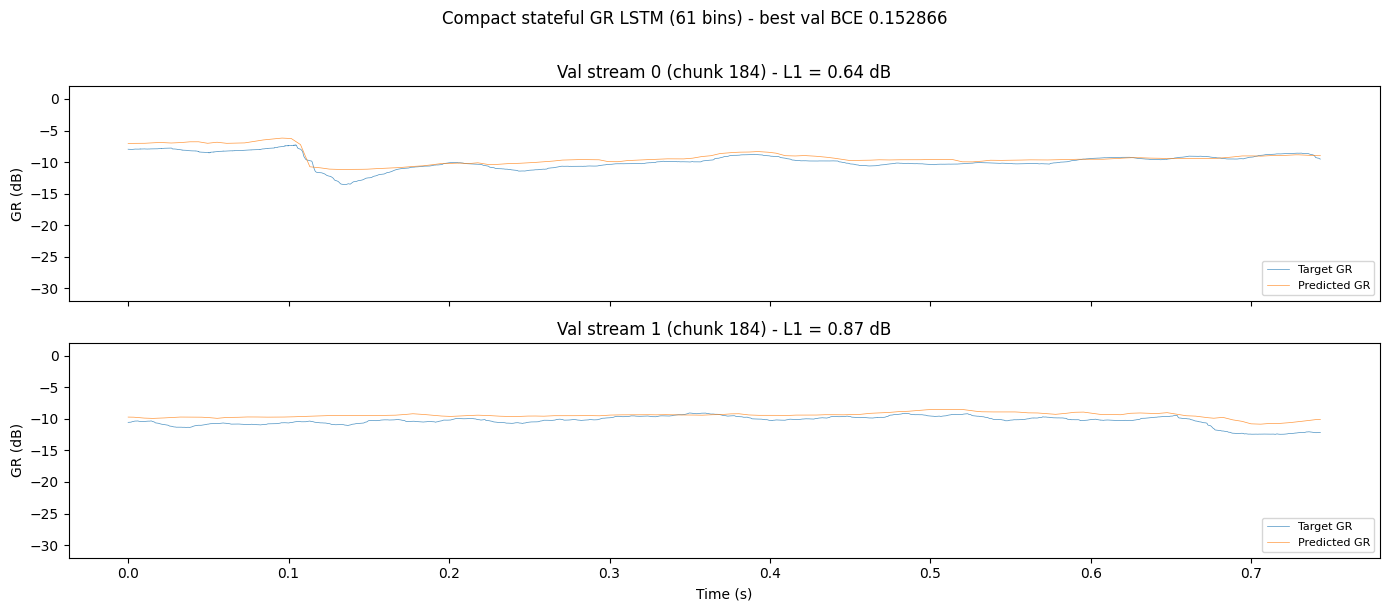

In [11]:
# == 8. Evaluate: predicted vs target GR envelope ==
# Streams the val tracks in order so the LSTM state settles (stateful), then
# plots a mid-track chunk per stream.

import matplotlib.pyplot as plt
import numpy as np

ckpt = torch.load(best_cb.best_model_path, map_location="cuda", weights_only=False)
system.load_state_dict(ckpt["state_dict"])
system.eval().cuda()
print(f"Loaded best checkpoint: {best_cb.best_model_path}")

val_steps = list(dm.val_dataloader())
pick = min(len(val_steps) // 2, len(val_steps) - 1)

state = None
with torch.no_grad():
    for i, (dry, gr_db, mask, reset) in enumerate(val_steps):
        dry = dry.cuda()
        if bool(reset):
            state = None
        logits, state = system.model(dry, state, return_state=True)
        state = (state[0].detach(), state[1].detach())
        if i == pick:
            T = dry.shape[-1]
            pred_db = system.model.to_db(logits, T=T).cpu().numpy()
            target_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX).numpy()
            valid = mask.bool()
            break

rows = torch.nonzero(valid).squeeze(1).tolist()
n_plots = min(4, len(rows))
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]
t = np.arange(pred_db.shape[-1]) / SAMPLE_RATE
for ax, i in zip(axes, rows[:n_plots]):
    ax.plot(t, target_db[i, 0], label="Target GR", alpha=0.8, linewidth=0.5)
    ax.plot(t, pred_db[i, 0], label="Predicted GR", alpha=0.8, linewidth=0.5)
    l1 = float(np.mean(np.abs(pred_db[i, 0] - target_db[i, 0])))
    ax.set_ylabel("GR (dB)"); ax.set_title(f"Val stream {i} (chunk {pick}) - L1 = {l1:.2f} dB")
    ax.legend(loc="lower right", fontsize=8); ax.set_ylim(GR_DB_MIN - 2, 2)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Compact stateful GR LSTM ({GR_NUM_BINS} bins) - best val BCE "
             f"{best_cb.best_model_score:.6f}", y=1.01)
fig.tight_layout()
plot_path = os.path.join(RUN_DIR, "eval_gr_comparison.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {plot_path}")
plt.show()